# Quantum Convolutional Neural Network

This notebook demonstrates the package-client QCNN workflow implemented in `qml.qcnn`.

The model uses:

- a trainable four-qubit embedding
- shared convolution-style two-qubit blocks
- pooling-style entangling reductions before final readout

The notebook remains a thin client of the package API.

In [1]:
from qml.qcnn import run_qcnn

## Run a QCNN experiment

Train a small QCNN classifier on the two-moons dataset.

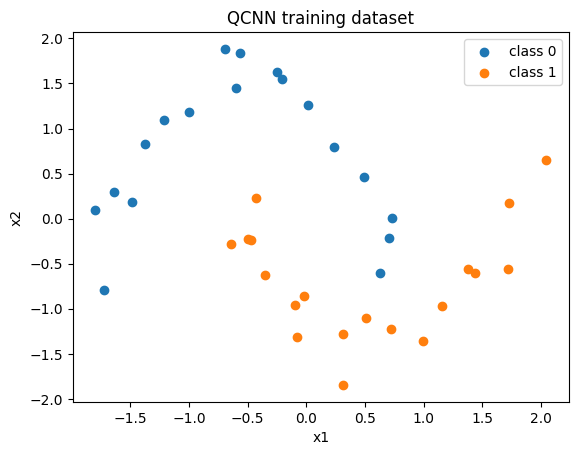

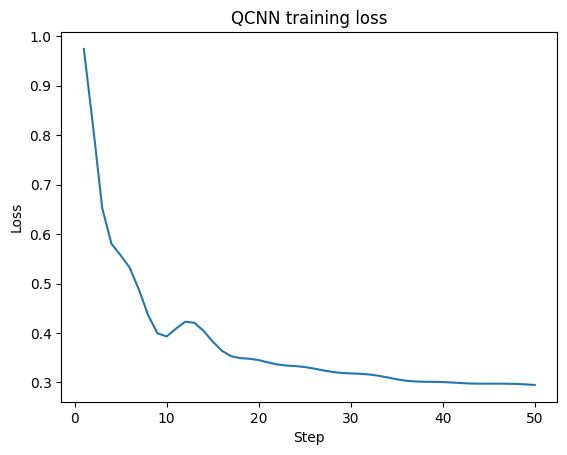

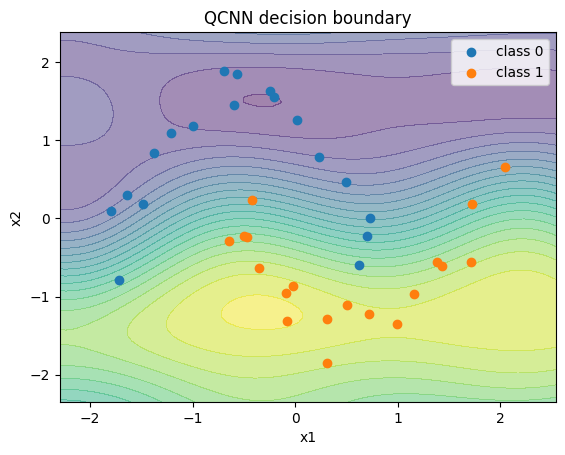

Train accuracy: 0.8648648648648649
Test accuracy: 0.8461538461538461
Final loss: 0.29350643128269527


In [2]:
result = run_qcnn(
    dataset="moons",
    n_samples=50,
    noise=0.1,
    test_size=0.25,
    seed=123,
    steps=50,
    step_size=0.1,
    plot=True,
    save=True,
)

print("Train accuracy:", result["train_accuracy"])
print("Test accuracy:", result["test_accuracy"])
print("Final loss:", result["final_loss"])

## Inspect learned parameter blocks

In [3]:
print("Embedding params shape:", result["embedding_params"].shape)
print("First convolution block shape:", result["conv1_params"].shape)
print("Second convolution block shape:", result["conv2_params"].shape)
print("Dense readout params shape:", result["dense_params"].shape)

Embedding params shape: (4, 3)
First convolution block shape: (2, 6)
Second convolution block shape: (1, 6)
Dense readout params shape: (2,)


## Compare dataset choices

In [5]:
for dataset in ["moons", "circles", "blobs", "xor"]:
    res = run_qcnn(
        dataset=dataset,
        n_samples=50,
        noise=0.1,
        seed=123,
        steps=25,
        plot=False,
        save=False,
    )

    print()
    print(dataset)
    print("  train accuracy:", res["train_accuracy"])
    print("  test accuracy:", res["test_accuracy"])


moons
  train accuracy: 0.8648648648648649
  test accuracy: 0.8461538461538461

circles
  train accuracy: 0.8108108108108109
  test accuracy: 0.8461538461538461

blobs
  train accuracy: 1.0
  test accuracy: 1.0

xor
  train accuracy: 0.8918918918918919
  test accuracy: 0.9230769230769231


## Finite-shot execution

In [8]:
result_shots = run_qcnn(
    dataset="moons",
    n_samples=50,
    noise=0.1,
    seed=123,
    steps=25,
    shots=50,
    plot=False,
    save=False,
)

print("Finite-shot train accuracy:", result_shots["train_accuracy"])
print("Finite-shot test accuracy:", result_shots["test_accuracy"])
print("Finite-shot final loss:", result_shots["final_loss"])

KeyboardInterrupt: 